# Alternating Group A_n: Spherical Training with Unshared Embedding

This notebook demonstrates Stage 1 training on the **alternating group A_n** with **unshared embedding** (`share_embed=False`).

**Task**: Permutation composition σ ∘ τ (non-commutative)

**Group**: A_n = even permutations of n elements (subgroup of S_n with |A_n| = n!/2)

**Basis**: Irreducible representations of A_n

**Key differences from S_n**:
- A_n has fewer conjugacy classes, hence fewer irreps
- Some S_n irreps merge when restricted to A_n
- Self-conjugate S_n irreps split into two A_n irreps

In [57]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from math import factorial

from src.tasks import AlternatingGroupMultiplication
from src.basis import AlternatingGroupBasis
from src.model import WideNetworkScaleSphere
from src.utils import (
    cross_entropy_high_precision,
    accuracy,
    project_gradient_to_tangent_space,
    normalize_to_pi,
)

plt.rcParams['mathtext.fontset'] = 'cm'

# Custom colormap: blue -> white -> red
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    ['#0D2758', 'white', '#A32015'],
    N=256
)

## 1. Configuration

In [58]:
# === Alternating Group Configuration ===
N_DEGREE = 4  # A_4 has 12 elements (4!/2 = 12)
              # A_3 has 3 elements (3!/2 = 3)
              # A_5 has 60 elements (5!/2 = 60)

# Model
WIDTH = 512
ACT_TYPE = 'Quad'
INIT_SCALE = 0.5
SHARE_EMBED = False  # Unshared for non-commutative operation

# Training
LR = 1e-3
NUM_EPOCHS = 2000
PRINT_EVERY = 500

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cpu')

vocab_size = factorial(N_DEGREE) // 2
print(f"Alternating Group: A_{N_DEGREE}")
print(f"Group size: |A_{N_DEGREE}| = {N_DEGREE}!/2 = {vocab_size}")
print(f"Dataset size: {vocab_size}² = {vocab_size**2} pairs")
print(f"Model: width={WIDTH}, activation={ACT_TYPE}, share_embed={SHARE_EMBED}")

Alternating Group: A_4
Group size: |A_4| = 4!/2 = 12
Dataset size: 12² = 144 pairs
Model: width=512, activation=Quad, share_embed=False


## 2. Initialize Task, Basis, and Model

In [59]:
# Create task and basis
task = AlternatingGroupMultiplication(n=N_DEGREE)
basis = AlternatingGroupBasis(n=N_DEGREE)

print(f"Task: {task}")
print(f"Basis: {basis}")
print(f"\nIrreducible representations (label -> dimension):")
for label, dim in basis.irrep_dimensions.items():
    print(f"  {label}: dim = {dim} -> contributes {dim**2} basis functions")
print(f"\nTotal basis functions: {sum(d**2 for d in basis.irrep_dimensions.values())} = {vocab_size}")

Task: AlternatingGroupMultiplication(n=4, vocab_size=12)
Basis: AlternatingGroupBasis(n=4, size=12, irreps={trivial:1, omega:1, omega_conj:1, standard:3})

Irreducible representations (label -> dimension):
  trivial: dim = 1 -> contributes 1 basis functions
  omega: dim = 1 -> contributes 1 basis functions
  omega_conj: dim = 1 -> contributes 1 basis functions
  standard: dim = 3 -> contributes 9 basis functions

Total basis functions: 12 = 12


In [60]:
# Generate data
data, labels = task.generate_all_data(device)

# Create model
model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f"\nModel architecture:")
print(f"  W_in:  {model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {model.W_out.shape}")
print(f"  scale_in:  {model.scale_in.item():.4f}")
print(f"  scale_out: {model.scale_out.item():.4f}")
print(f"\nDataset: {len(data)} samples")


Model architecture:
  W_in:  torch.Size([512, 24])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([12, 512])
  scale_in:  0.5000
  scale_out: 0.5000

Dataset: 144 samples


## 3. Run Stage 1 Training (Projected GD on Sphere)

In [61]:
# Save initial weights before training
W_in_init = model.W_in.detach().cpu().clone()
W_out_init = model.W_out.detach().cpu().clone()

# Freeze scales
model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

# Optimizer for directions only
optimizer = optim.Adam([model.W_in, model.W_out], lr=LR)

# Training history
losses = []
accuracies = []

print("=" * 60)
print("Stage 1: Projected GD (Directions only, Scale fixed)")
print("=" * 60)
print(f"Fixed scale_in = {model.scale_in.item():.4f}, scale_out = {model.scale_out.item():.4f}")

for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    
    # Forward
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc = accuracy(logits, labels)
    
    # Backward
    loss.backward()
    
    # Project gradients onto tangent space
    with torch.no_grad():
        model.W_in.grad = project_gradient_to_tangent_space(
            model.W_in.data, model.W_in.grad, dim=1
        )
        model.W_out.grad = project_gradient_to_tangent_space(
            model.W_out.data, model.W_out.grad, dim=0
        )
    
    # Step
    optimizer.step()
    
    # Project back onto sphere
    model.normalize_directions()
    
    # Record
    losses.append(loss.item())
    accuracies.append(acc)
    
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f}")

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")

Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Epoch     0 | Loss: 2.484912 | Acc: 0.1042
Epoch   500 | Loss: 2.483119 | Acc: 1.0000
Epoch  1000 | Loss: 2.483105 | Acc: 1.0000
Epoch  1500 | Loss: 2.483105 | Acc: 1.0000

Final | Loss: 2.483105 | Acc: 1.0000


## 4. Single Frequency Phenomenon (Representation Analysis)

For `share_embed=False`, W_in has shape `(width, 2*vocab_size)` where:
- First half `W_in[:, :vocab_size]` corresponds to position 1 (σ)
- Second half `W_in[:, vocab_size:]` corresponds to position 2 (τ)

The Fourier transform on A_n uses irreducible representations.

In [62]:
# Get trained weights
W_in = model.W_in.detach().cpu()
W_out = model.W_out.detach().cpu()

# Number of neurons
M = WIDTH

# Split W_in into position 1 and position 2 (trained)
W_in_pos1 = W_in[:, :vocab_size]
W_in_pos2 = W_in[:, vocab_size:]

# Split W_in_init into position 1 and position 2 (initial)
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

print(f"W_in shape: {W_in.shape}")
print(f"W_in_pos1 (σ): {W_in_pos1.shape}")
print(f"W_in_pos2 (τ): {W_in_pos2.shape}")
print(f"W_out: {W_out.shape}")

# Normalize each part (trained)
W_in_pos1_norm = W_in_pos1 / W_in_pos1.norm(dim=1, keepdim=True)
W_in_pos2_norm = W_in_pos2 / W_in_pos2.norm(dim=1, keepdim=True)
W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)

# Normalize each part (initial)
W_in_init_pos1_norm = W_in_init_pos1 / W_in_init_pos1.norm(dim=1, keepdim=True)
W_in_init_pos2_norm = W_in_init_pos2 / W_in_init_pos2.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

# Apply Fourier transform (trained)
W_in_pos1_dft = basis.transform(W_in_pos1_norm)
W_in_pos2_dft = basis.transform(W_in_pos2_norm)
W_out_dft = basis.transform(W_out_norm.T)

# Apply Fourier transform (initial)
W_in_init_pos1_dft = basis.transform(W_in_init_pos1_norm)
W_in_init_pos2_dft = basis.transform(W_in_init_pos2_norm)
W_out_init_dft = basis.transform(W_out_init_norm.T)

# Get magnitudes (trained)
W_in_pos1_mag = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag = torch.abs(W_in_pos2_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()

# Get magnitudes (initial)
W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"\nDFT shapes:")
print(f"W_in_pos1_dft: {W_in_pos1_dft.shape}")
print(f"W_in_pos2_dft: {W_in_pos2_dft.shape}")
print(f"W_out_dft: {W_out_dft.shape}")

# Compute irrep boundaries for grouping
irrep_boundaries = []
irrep_labels_list = []
curr_idx = 0
for label in basis.irrep_labels:
    dim = basis.irrep_dimensions[label]
    irrep_boundaries.append((curr_idx, curr_idx + dim * dim))
    irrep_labels_list.append(f"{label}\n(d={dim})")
    curr_idx += dim * dim

print(f"\nIrrep blocks: {irrep_boundaries}")

W_in shape: torch.Size([512, 24])
W_in_pos1 (σ): torch.Size([512, 12])
W_in_pos2 (τ): torch.Size([512, 12])
W_out: torch.Size([12, 512])

DFT shapes:
W_in_pos1_dft: torch.Size([512, 12])
W_in_pos2_dft: torch.Size([512, 12])
W_out_dft: torch.Size([512, 12])

Irrep blocks: [(0, 1), (1, 2), (2, 3), (3, 12)]


### 4.1 Single Representation Phenomenon (Representation-Level View)

We compute the total energy in each irrep block:
$$E_\lambda^{(m)} = \sum_{i,j=1}^{d_\lambda} |\hat{w}_m^{(\lambda, i, j)}|^2$$

In [63]:
# Compute energy per representation for each neuron
def compute_irrep_energy(mag_matrix, boundaries):
    """Compute total squared magnitude in each irrep block."""
    n_neurons = mag_matrix.shape[0]
    n_irreps = len(boundaries)
    energy = np.zeros((n_neurons, n_irreps))
    
    for i, (start, end) in enumerate(boundaries):
        energy[:, i] = np.sum(mag_matrix[:, start:end] ** 2, axis=1)
    
    return energy

# Compute energies (trained and init)
energy_pos1 = compute_irrep_energy(W_in_pos1_mag, irrep_boundaries)
energy_pos2 = compute_irrep_energy(W_in_pos2_mag, irrep_boundaries)
energy_out = compute_irrep_energy(W_out_mag, irrep_boundaries)

energy_pos1_init = compute_irrep_energy(W_in_init_pos1_mag, irrep_boundaries)
energy_pos2_init = compute_irrep_energy(W_in_init_pos2_mag, irrep_boundaries)
energy_out_init = compute_irrep_energy(W_out_init_mag, irrep_boundaries)

# For A4: omega and omega_conj are conjugate irreps - their coefficients are complex conjugates
# So |ω_coeff|² = |ω̄_coeff|² always. We should group them together for single-irrep analysis.
CONJUGATE_PAIRS = {
    'omega': 'omega_conj',
    'omega_conj': 'omega',
}

def get_grouped_irrep_labels():
    """Get irrep labels with conjugate pairs grouped."""
    grouped = []
    seen = set()
    for label in basis.irrep_labels:
        if label in seen:
            continue
        if label in CONJUGATE_PAIRS:
            conj = CONJUGATE_PAIRS[label]
            grouped.append(f"{label}+{conj}")
            seen.add(label)
            seen.add(conj)
        else:
            grouped.append(label)
            seen.add(label)
    return grouped

def compute_grouped_energy(energy, irrep_labels):
    """Combine energy for conjugate irrep pairs."""
    n_neurons = energy.shape[0]
    grouped_labels = get_grouped_irrep_labels()
    grouped_energy = np.zeros((n_neurons, len(grouped_labels)))
    
    for gi, glabel in enumerate(grouped_labels):
        if '+' in glabel:
            # Conjugate pair - sum both
            parts = glabel.split('+')
            for part in parts:
                idx = irrep_labels.index(part)
                grouped_energy[:, gi] += energy[:, idx]
        else:
            idx = irrep_labels.index(glabel)
            grouped_energy[:, gi] = energy[:, idx]
    
    return grouped_energy, grouped_labels

# Compute grouped energy (combining omega + omega_conj)
energy_pos1_grouped, grouped_labels = compute_grouped_energy(energy_pos1, basis.irrep_labels)
energy_pos2_grouped, _ = compute_grouped_energy(energy_pos2, basis.irrep_labels)
energy_out_grouped, _ = compute_grouped_energy(energy_out, basis.irrep_labels)

print("Energy per irrep (first 8 neurons, position 1):")
print("(Note: omega and omega_conj are conjugate irreps, shown separately and grouped)")
print(f"\n{'Neuron':<8}", end="")
for label in basis.irrep_labels:
    print(f"{label:<12}", end="")
print()
print("-" * (8 + 12 * len(basis.irrep_labels)))
for m in range(8):
    print(f"{m:<8}", end="")
    for e in energy_pos1[m]:
        print(f"{e:<12.4f}", end="")
    print()

print(f"\nGrouped energy (omega+omega_conj combined):")
print(f"{'Neuron':<8}", end="")
for label in grouped_labels:
    print(f"{label:<20}", end="")
print()
print("-" * (8 + 20 * len(grouped_labels)))
for m in range(8):
    print(f"{m:<8}", end="")
    for e in energy_pos1_grouped[m]:
        print(f"{e:<20.4f}", end="")
    print()

Energy per irrep (first 8 neurons, position 1):
(Note: omega and omega_conj are conjugate irreps, shown separately and grouped)

Neuron  trivial     omega       omega_conj  standard    
--------------------------------------------------------
0       0.0000      0.0000      0.0000      1.0000      
1       0.0000      0.0000      0.0000      1.0000      
2       0.0000      0.0000      0.0000      1.0000      
3       0.0000      0.0000      0.0000      1.0000      
4       0.0000      0.5000      0.5000      0.0000      
5       0.0000      0.0000      0.0000      1.0000      
6       0.0000      0.0000      0.0000      1.0000      
7       0.0000      0.0000      0.0000      1.0000      

Grouped energy (omega+omega_conj combined):
Neuron  trivial             omega+omega_conj    standard            
--------------------------------------------------------------------
0       0.0000              0.0000              1.0000              
1       0.0000              0.0000              1

### 4.2 Fine-Grained View: Individual Basis Functions

Skipping trivial: no neurons with significant energy


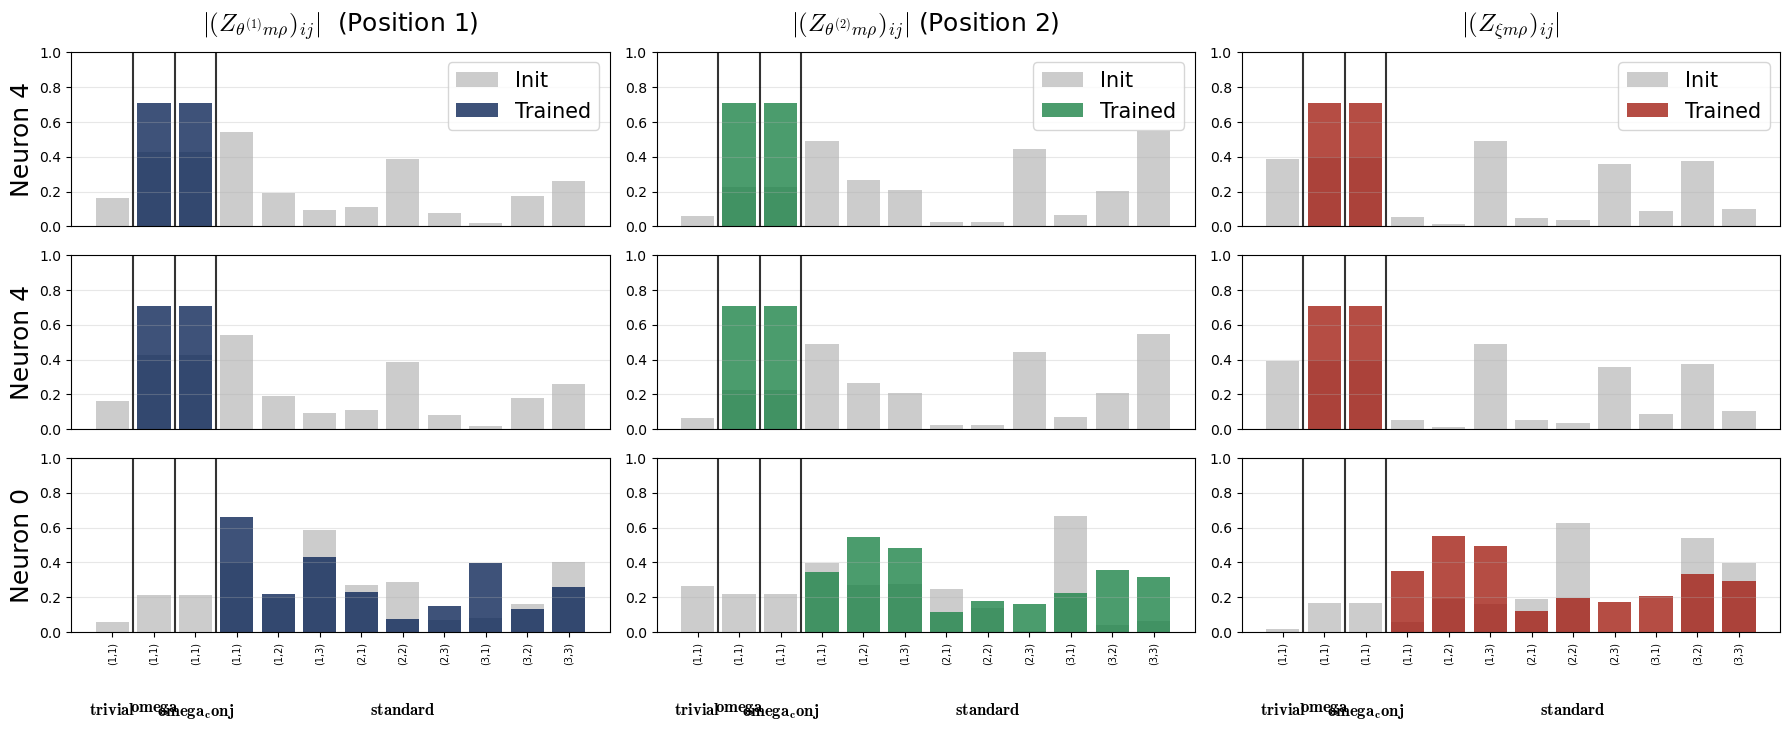

In [64]:
# Plot DFT comparison: Init (gray) vs Stage 1 (color)
freq_indices = np.arange(vocab_size)

# High threshold for specialization
ENERGY_THRESHOLD = 0.99

# Find one neuron per irrep
neurons_per_irrep = []
for label in basis.irrep_labels:
    irrep_idx = basis.irrep_labels.index(label)
    dominant_neurons = np.where(energy_pos1[:, irrep_idx] > ENERGY_THRESHOLD)[0]
    if len(dominant_neurons) > 0:
        neurons_per_irrep.append((label, dominant_neurons[0]))
    else:
        # Lower threshold fallback
        dominant_neurons = np.where(energy_pos1[:, irrep_idx] > 0.5)[0]
        if len(dominant_neurons) > 0:
            neurons_per_irrep.append((label, dominant_neurons[0]))
        else:
            print(f"Skipping {label}: no neurons with significant energy")

num_rows = len(neurons_per_irrep)

# Build basis labels (i,j) for each frequency (1-based indexing)
basis_labels = []
for label in basis.irrep_labels:
    d = basis.irrep_dimensions[label]
    for i in range(d):
        for j in range(d):
            basis_labels.append(f'({i+1},{j+1})')

# Compute center position for each irrep block
irrep_centers = []
for start, end in irrep_boundaries:
    center = (start + end - 1) / 2
    irrep_centers.append(center)

fig, axes = plt.subplots(num_rows, 3, figsize=(18, 2.5 * num_rows))
if num_rows == 1:
    axes = axes.reshape(1, -1)

for row, (label, m) in enumerate(neurons_per_irrep):
    is_last_row = (row == num_rows - 1)
    
    # Position 1 - Blue
    ax = axes[row, 0]
    ax.bar(freq_indices, W_in_init_pos1_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos1_mag[m], alpha=0.8, color='#0D2758', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylabel(f'Neuron {m}', fontsize=18)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'$|(Z_{\theta^{(1)}m\rho})_{ij}|$  (Position 1)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=7, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(f'$\\mathbf{{{lbl}}}$', xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=12, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Position 2 - Green
    ax = axes[row, 1]
    ax.bar(freq_indices, W_in_init_pos2_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos2_mag[m], alpha=0.8, color='#1E8449', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'$|(Z_{\theta^{(2)}m\rho})_{ij}|$ (Position 2)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=7, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(f'$\\mathbf{{{lbl}}}$', xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=12, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Output - Red
    ax = axes[row, 2]
    ax.bar(freq_indices, W_out_init_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_out_mag[m], alpha=0.8, color='#A32015', label='Trained')
    for start, end in irrep_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'$|(Z_{\xi m\rho})_{ij}|$', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=7, rotation=90)
        for i, (center, lbl) in enumerate(zip(irrep_centers, basis.irrep_labels)):
            ax.annotate(f'$\\mathbf{{{lbl}}}$', xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=12, fontweight='bold')
    else:
        ax.set_xticks([])

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('../figures/alternating_group_dft_magnitude.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 5. Phase Alignment via Matrix Product

We check if $\hat{W}_{in}^{(1)}(\lambda) \cdot \hat{W}_{in}^{(2)}(\lambda) \cdot \hat{W}_{out}(\lambda)^\dagger \approx \text{real matrix}$

In [65]:
# Extract matrix-valued Fourier coefficients for each irrep
def extract_irrep_matrices(dft_coeffs, irrep_labels, irrep_dims):
    """Extract d_λ × d_λ matrices from flattened DFT coefficients."""
    n_neurons = dft_coeffs.shape[0]
    irrep_matrices = {}
    
    curr_idx = 0
    for label in irrep_labels:
        d = irrep_dims[label]
        block = dft_coeffs[:, curr_idx:curr_idx + d*d]
        irrep_matrices[label] = block.reshape(n_neurons, d, d)
        curr_idx += d * d
    
    return irrep_matrices

# Extract matrices for each position and output
W_in_pos1_matrices = extract_irrep_matrices(W_in_pos1_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_in_pos2_matrices = extract_irrep_matrices(W_in_pos2_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_out_matrices = extract_irrep_matrices(W_out_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)

print("Extracted irrep matrices:")
for label, mat in W_in_pos1_matrices.items():
    d = basis.irrep_dimensions[label]
    print(f"  {label}: shape = {mat.shape} (neurons × {d} × {d})")

Extracted irrep matrices:
  trivial: shape = (512, 1, 1) (neurons × 1 × 1)
  omega: shape = (512, 1, 1) (neurons × 1 × 1)
  omega_conj: shape = (512, 1, 1) (neurons × 1 × 1)
  standard: shape = (512, 3, 3) (neurons × 3 × 3)


In [ ]:
# Verify that Fourier coefficients are genuinely complex (not purely real)
# For conjugate irrep pairs (omega, omega_conj), coefficients should be complex conjugates

ENERGY_THRESHOLD = 0.90

print("Verifying Fourier coefficients are complex (|Im|/|total| ratio)")
print("=" * 85)
print(f"{'Irrep (grouped)':<22} {'# Neurons':<12} {'W1 Im ratio':<15} {'W2 Im ratio':<15} {'Complex?':<12}")
print("-" * 85)

for gi, glabel in enumerate(grouped_labels):
    specialized = np.where(energy_pos1_grouped[:, gi] > ENERGY_THRESHOLD)[0]
    
    if len(specialized) == 0:
        print(f"{glabel:<22} {'0':<12} {'N/A':<15} {'N/A':<15} {'(skipped)':<12}")
        continue
    
    if '+' in glabel:
        # Conjugate pair - use one of them (they have same magnitude)
        parts = glabel.split('+')
        label = parts[0]
        W1_mats = W_in_pos1_matrices[label][specialized]
        W2_mats = W_in_pos2_matrices[label][specialized]
    else:
        label = glabel
        W1_mats = W_in_pos1_matrices[label][specialized]
        W2_mats = W_in_pos2_matrices[label][specialized]
    
    # Compute mean imaginary ratio across specialized neurons
    im_ratios_w1 = []
    im_ratios_w2 = []
    for m in range(len(specialized)):
        im_ratios_w1.append(np.linalg.norm(W1_mats[m].imag, 'fro') / (np.linalg.norm(W1_mats[m], 'fro') + 1e-10))
        im_ratios_w2.append(np.linalg.norm(W2_mats[m].imag, 'fro') / (np.linalg.norm(W2_mats[m], 'fro') + 1e-10))
    
    mean_im_w1 = np.mean(im_ratios_w1)
    mean_im_w2 = np.mean(im_ratios_w2)
    is_complex = "YES" if (mean_im_w1 > 0.1 or mean_im_w2 > 0.1) else "NO (real)"
    
    print(f"{glabel:<22} {len(specialized):<12} {mean_im_w1:<15.4f} {mean_im_w2:<15.4f} {is_complex:<12}")

print("-" * 85)

# For conjugate pairs, verify that coefficients are indeed conjugates
if any('+' in gl for gl in grouped_labels):
    print("\nConjugate pair verification (ω and ω̄ coefficients should be conjugates):")
    for glabel in grouped_labels:
        if '+' not in glabel:
            continue
        parts = glabel.split('+')
        label1, label2 = parts[0], parts[1]
        specialized = np.where(energy_pos1_grouped[:, grouped_labels.index(glabel)] > ENERGY_THRESHOLD)[0]
        
        if len(specialized) == 0:
            continue
        
        # Check if W[ω] ≈ conj(W[ω̄])
        conj_errors = []
        for m in specialized[:10]:  # Check first 10
            w1_omega = W_in_pos1_matrices[label1][m, 0, 0]
            w1_omega_bar = W_in_pos1_matrices[label2][m, 0, 0]
            conj_errors.append(np.abs(w1_omega - w1_omega_bar.conj()))
        
        mean_err = np.mean(conj_errors)
        print(f"  {glabel}: Mean |W[ω] - W[ω̄]*| = {mean_err:.2e} {'✓' if mean_err < 1e-10 else '✗'}")

Alternating Group: A_4
Group size: |A_4| = 4!/2 = 12
Dataset size: 12² = 144 pairs
Model: width=256, activation=Quad, share_embed=False


In [67]:
# Compute the matrix product W1 @ W2 @ Wout^†
def compute_phase_product(W1, W2, Wout):
    """Compute W1 @ W2 @ Wout^† for each neuron."""
    n_neurons = W1.shape[0]
    d = W1.shape[1]
    product = np.zeros((n_neurons, d, d), dtype=complex)
    
    for m in range(n_neurons):
        product[m] = W1[m] @ W2[m] @ Wout[m].conj().T
    
    return product

def compute_realness_ratio(product):
    """Compute ||Im||_F / ||total||_F for each neuron's matrix."""
    imag_norms = np.array([np.linalg.norm(product[m].imag, 'fro') for m in range(product.shape[0])])
    total_norms = np.array([np.linalg.norm(product[m], 'fro') for m in range(product.shape[0])])
    return imag_norms / (total_norms + 1e-10)

ENERGY_THRESHOLD = 0.90

print("Phase alignment check: Is W1 @ W2 @ Wout^† approximately real?")
print("(Using GROUPED energy for conjugate irrep pairs)")
print("=" * 80)
print(f"{'Irrep (grouped)':<25} {'# Neurons':<12} {'Mean |Im|/|tot|':<20} {'Real?':<15}")
print("-" * 80)

all_ratios = []

for gi, glabel in enumerate(grouped_labels):
    # Find neurons specialized to this grouped irrep
    dominant_neurons = np.where(energy_pos1_grouped[:, gi] > ENERGY_THRESHOLD)[0]
    
    if len(dominant_neurons) == 0:
        print(f"{glabel:<25} {'0':<12} {'N/A':<20} {'(skipped)':<15}")
        continue
    
    if '+' in glabel:
        # Conjugate pair: compute combined product
        # For conjugate irreps ρ and ρ̄, the combined contribution is:
        # W1[ρ]·W2[ρ]·Wout[ρ]† + W1[ρ̄]·W2[ρ̄]·Wout[ρ̄]†
        # Since coefficients are conjugates, this sum should be real
        parts = glabel.split('+')
        label1, label2 = parts[0], parts[1]
        
        W1_rho = W_in_pos1_matrices[label1]
        W2_rho = W_in_pos2_matrices[label1]
        Wout_rho = W_out_matrices[label1]
        
        W1_rho_bar = W_in_pos1_matrices[label2]
        W2_rho_bar = W_in_pos2_matrices[label2]
        Wout_rho_bar = W_out_matrices[label2]
        
        product_rho = compute_phase_product(W1_rho, W2_rho, Wout_rho)
        product_rho_bar = compute_phase_product(W1_rho_bar, W2_rho_bar, Wout_rho_bar)
        
        # Combined product (should be real for proper phase alignment)
        combined_product = product_rho + product_rho_bar
        
        ratios = compute_realness_ratio(combined_product[dominant_neurons])
        mean_ratio = np.mean(ratios)
        all_ratios.extend(ratios)
        
        is_real = "YES" if mean_ratio < 0.1 else "NO"
        print(f"{glabel:<25} {len(dominant_neurons):<12} {mean_ratio:<20.4f} {is_real:<15}")
    else:
        # Non-conjugate irrep
        label = glabel
        W1 = W_in_pos1_matrices[label]
        W2 = W_in_pos2_matrices[label]
        Wout = W_out_matrices[label]
        
        product = compute_phase_product(W1, W2, Wout)
        
        ratios = compute_realness_ratio(product[dominant_neurons])
        mean_ratio = np.mean(ratios)
        all_ratios.extend(ratios)
        
        is_real = "YES" if mean_ratio < 0.1 else "NO"
        print(f"{glabel:<25} {len(dominant_neurons):<12} {mean_ratio:<20.4f} {is_real:<15}")

print("-" * 80)
if len(all_ratios) > 0:
    print(f"\nOverall: Mean |Im|/|total| ratio = {np.mean(all_ratios):.4f}")
    print(f"Phase alignment {'SATISFIED' if np.mean(all_ratios) < 0.1 else 'NOT SATISFIED'} (threshold: 0.1)")

Phase alignment check: Is W1 @ W2 @ Wout^† approximately real?
(Using GROUPED energy for conjugate irrep pairs)
Irrep (grouped)           # Neurons    Mean |Im|/|tot|      Real?          
--------------------------------------------------------------------------------
trivial                   0            N/A                  (skipped)      
omega+omega_conj          86           0.0000               YES            
standard                  426          0.0000               YES            
--------------------------------------------------------------------------------

Overall: Mean |Im|/|total| ratio = 0.0000
Phase alignment SATISFIED (threshold: 0.1)


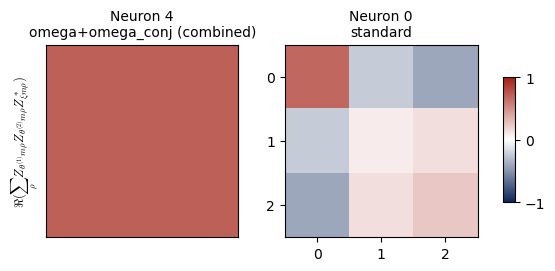

In [68]:
# Phase alignment visualization (Real part only)
# For conjugate pairs, show the COMBINED product (ρ + ρ̄)
ENERGY_THRESHOLD = 0.90

irreps_with_neurons = []
for gi, glabel in enumerate(grouped_labels):
    dominant_neurons = np.where(energy_pos1_grouped[:, gi] > ENERGY_THRESHOLD)[0]
    if len(dominant_neurons) > 0:
        irreps_with_neurons.append((glabel, dominant_neurons[0]))
    else:
        # Fallback to lower threshold
        dominant_neurons = np.where(energy_pos1_grouped[:, gi] > 0.5)[0]
        if len(dominant_neurons) > 0:
            irreps_with_neurons.append((glabel, dominant_neurons[0]))

n_irreps = len(irreps_with_neurons)

if n_irreps > 0:
    fig, axes = plt.subplots(1, n_irreps, figsize=(3 * n_irreps, 2.5),
                             gridspec_kw={'wspace': 0.15})
    if n_irreps == 1:
        axes = [axes]

    for col, (glabel, m) in enumerate(irreps_with_neurons):
        if '+' in glabel:
            # Conjugate pair: show combined product
            parts = glabel.split('+')
            label1, label2 = parts[0], parts[1]
            
            W1_rho = W_in_pos1_matrices[label1]
            W2_rho = W_in_pos2_matrices[label1]
            Wout_rho = W_out_matrices[label1]
            W1_rho_bar = W_in_pos1_matrices[label2]
            W2_rho_bar = W_in_pos2_matrices[label2]
            Wout_rho_bar = W_out_matrices[label2]
            
            product_rho = compute_phase_product(W1_rho, W2_rho, Wout_rho)
            product_rho_bar = compute_phase_product(W1_rho_bar, W2_rho_bar, Wout_rho_bar)
            
            product = product_rho[m] + product_rho_bar[m]  # Combined
            d = 1  # Both are 1D irreps
        else:
            label = glabel
            W1 = W_in_pos1_matrices[label]
            W2 = W_in_pos2_matrices[label]
            Wout = W_out_matrices[label]
            
            full_product = compute_phase_product(W1, W2, Wout)
            product = full_product[m]
            d = basis.irrep_dimensions[label]
        
        ax = axes[col]
        im = ax.imshow(product.real, cmap=blue_white_red, vmin=-1, vmax=1)
        ax.set_xticks(range(d) if d > 1 else [])
        ax.set_yticks(range(d) if d > 1 else [])
        title = f'Neuron {m}\n{glabel}'
        if '+' in glabel:
            title += ' (combined)'
        ax.set_title(title, fontsize=10)
        if col == 0:
            ax.set_ylabel(r'$\Re(\sum_\rho Z_{\theta^{(1)}m\rho}Z_{\theta^{(2)}m\rho}Z_{\xi m\rho}^*)$', fontsize=9)

    fig.subplots_adjust(right=0.87)
    cbar_ax = fig.add_axes([0.90, 0.25, 0.02, 0.5])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_ticks([-1, 0, 1])

    plt.savefig('../figures/alternating_group_phase_alignment.jpg', format='jpg', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No neurons found with sufficient energy in any irrep.")

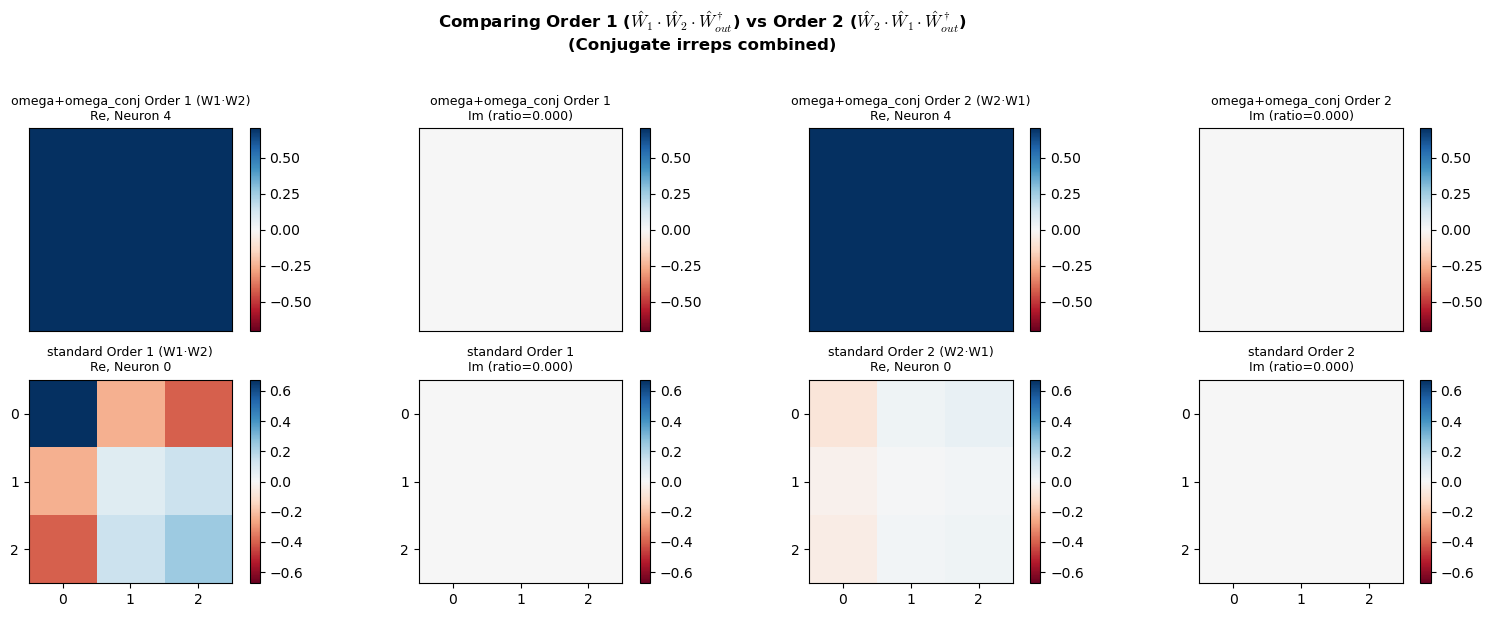

In [69]:
# Visualize both orderings for selected neurons per irrep (grouped)
# For conjugate pairs: show combined product (ρ + ρ̄)
# For each irrep: show Order 1 (Re, Im) and Order 2 (Re, Im) for one dominant neuron

ENERGY_THRESHOLD = 0.90

irreps_with_neurons = []
for gi, glabel in enumerate(grouped_labels):
    dominant_neurons = np.where(energy_pos1_grouped[:, gi] > ENERGY_THRESHOLD)[0]
    if len(dominant_neurons) > 0:
        irreps_with_neurons.append((glabel, dominant_neurons[0]))
    else:
        # Fallback to lower threshold
        dominant_neurons = np.where(energy_pos1_grouped[:, gi] > 0.5)[0]
        if len(dominant_neurons) > 0:
            irreps_with_neurons.append((glabel, dominant_neurons[0]))

n_rows = len(irreps_with_neurons)

if n_rows > 0:
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for row, (glabel, m) in enumerate(irreps_with_neurons):
        if '+' in glabel:
            # Conjugate pair: compute combined products
            parts = glabel.split('+')
            label1, label2 = parts[0], parts[1]
            d = 1  # Both are 1D
            
            W1_rho = W_in_pos1_matrices[label1]
            W2_rho = W_in_pos2_matrices[label1]
            Wout_rho = W_out_matrices[label1]
            W1_rho_bar = W_in_pos1_matrices[label2]
            W2_rho_bar = W_in_pos2_matrices[label2]
            Wout_rho_bar = W_out_matrices[label2]
            
            # Order 1: W1 @ W2 @ Wout†
            prod_rho_o1 = compute_phase_product(W1_rho, W2_rho, Wout_rho)
            prod_rho_bar_o1 = compute_phase_product(W1_rho_bar, W2_rho_bar, Wout_rho_bar)
            product_order1 = prod_rho_o1[m] + prod_rho_bar_o1[m]
            
            # Order 2: W2 @ W1 @ Wout†
            prod_rho_o2 = compute_phase_product(W2_rho, W1_rho, Wout_rho)
            prod_rho_bar_o2 = compute_phase_product(W2_rho_bar, W1_rho_bar, Wout_rho_bar)
            product_order2 = prod_rho_o2[m] + prod_rho_bar_o2[m]
        else:
            label = glabel
            d = basis.irrep_dimensions[label]
            
            W1 = W_in_pos1_matrices[label]
            W2 = W_in_pos2_matrices[label]
            Wout = W_out_matrices[label]
            
            prod_o1 = compute_phase_product(W1, W2, Wout)
            prod_o2 = compute_phase_product(W2, W1, Wout)
            product_order1 = prod_o1[m]
            product_order2 = prod_o2[m]
        
        vmax = max(np.abs(product_order1).max(), np.abs(product_order2).max())
        
        # Order 1: Real part
        ax = axes[row, 0]
        im = ax.imshow(product_order1.real, cmap='RdBu', vmin=-vmax, vmax=vmax)
        title = f'{glabel} Order 1 (W1·W2)\nRe, Neuron {m}'
        ax.set_title(title, fontsize=9)
        ax.set_xticks(range(d) if d > 1 else [])
        ax.set_yticks(range(d) if d > 1 else [])
        plt.colorbar(im, ax=ax, fraction=0.046)
        
        # Order 1: Imaginary part
        ax = axes[row, 1]
        im = ax.imshow(product_order1.imag, cmap='RdBu', vmin=-vmax, vmax=vmax)
        ratio1 = np.linalg.norm(product_order1.imag, 'fro') / (np.linalg.norm(product_order1, 'fro') + 1e-10)
        ax.set_title(f'{glabel} Order 1\nIm (ratio={ratio1:.3f})', fontsize=9)
        ax.set_xticks(range(d) if d > 1 else [])
        ax.set_yticks(range(d) if d > 1 else [])
        plt.colorbar(im, ax=ax, fraction=0.046)
        
        # Order 2: Real part
        ax = axes[row, 2]
        im = ax.imshow(product_order2.real, cmap='RdBu', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{glabel} Order 2 (W2·W1)\nRe, Neuron {m}', fontsize=9)
        ax.set_xticks(range(d) if d > 1 else [])
        ax.set_yticks(range(d) if d > 1 else [])
        plt.colorbar(im, ax=ax, fraction=0.046)
        
        # Order 2: Imaginary part
        ax = axes[row, 3]
        im = ax.imshow(product_order2.imag, cmap='RdBu', vmin=-vmax, vmax=vmax)
        ratio2 = np.linalg.norm(product_order2.imag, 'fro') / (np.linalg.norm(product_order2, 'fro') + 1e-10)
        ax.set_title(f'{glabel} Order 2\nIm (ratio={ratio2:.3f})', fontsize=9)
        ax.set_xticks(range(d) if d > 1 else [])
        ax.set_yticks(range(d) if d > 1 else [])
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(r'Comparing Order 1 ($\hat{W}_1 \cdot \hat{W}_2 \cdot \hat{W}_{out}^\dagger$) vs Order 2 ($\hat{W}_2 \cdot \hat{W}_1 \cdot \hat{W}_{out}^\dagger$)' + 
                 '\n(Conjugate irreps combined)', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No neurons found with sufficient energy in any irrep.")

In [70]:
# Summary: Compare both orderings for neurons with single-irrep specialization
# For conjugate pairs: use combined product (ρ + ρ̄)
# Metric: Frobenius norm of imaginary part / Frobenius norm of full matrix

ENERGY_THRESHOLD = 0.90

# Find neurons that fully specialize to one (grouped) irrep
specialized_neurons = []
for m in range(WIDTH):
    max_energy = np.max(energy_pos1_grouped[m])
    if max_energy > ENERGY_THRESHOLD:
        specialized_neurons.append(m)

print(f"Summary: Comparing both orderings for neurons with >{ENERGY_THRESHOLD*100:.0f}% energy in one irrep")
print(f"(Conjugate irreps omega+omega_conj are grouped together)")
print(f"Found {len(specialized_neurons)} specialized neurons out of {WIDTH}")
print("=" * 100)
print(f"{'Neuron':<8} {'Irrep (grouped)':<22} {'Order1 Ratio':<14} {'Order2 Ratio':<14} {'Better':<10} {'Real?':<8}")
print("-" * 100)

order1_ratios = []
order2_ratios = []

for m in specialized_neurons[:20]:  # Show first 20 specialized neurons
    # Find dominant grouped irrep for this neuron
    dom_irrep_idx = np.argmax(energy_pos1_grouped[m])
    glabel = grouped_labels[dom_irrep_idx]
    
    if '+' in glabel:
        # Conjugate pair
        parts = glabel.split('+')
        label1, label2 = parts[0], parts[1]
        
        W1_rho = W_in_pos1_matrices[label1][m]
        W2_rho = W_in_pos2_matrices[label1][m]
        Wout_rho = W_out_matrices[label1][m]
        W1_rho_bar = W_in_pos1_matrices[label2][m]
        W2_rho_bar = W_in_pos2_matrices[label2][m]
        Wout_rho_bar = W_out_matrices[label2][m]
        
        # Order 1: W1 @ W2 @ Wout† (combined)
        prod1_rho = W1_rho @ W2_rho @ Wout_rho.conj().T
        prod1_rho_bar = W1_rho_bar @ W2_rho_bar @ Wout_rho_bar.conj().T
        product1 = prod1_rho + prod1_rho_bar
        
        # Order 2: W2 @ W1 @ Wout† (combined)
        prod2_rho = W2_rho @ W1_rho @ Wout_rho.conj().T
        prod2_rho_bar = W2_rho_bar @ W1_rho_bar @ Wout_rho_bar.conj().T
        product2 = prod2_rho + prod2_rho_bar
    else:
        label = glabel
        W1 = W_in_pos1_matrices[label][m]
        W2 = W_in_pos2_matrices[label][m]
        Wout = W_out_matrices[label][m]
        
        # Order 1: W1 @ W2 @ Wout†
        product1 = W1 @ W2 @ Wout.conj().T
        
        # Order 2: W2 @ W1 @ Wout†
        product2 = W2 @ W1 @ Wout.conj().T
    
    ratio1 = np.linalg.norm(product1.imag, 'fro') / (np.linalg.norm(product1, 'fro') + 1e-10)
    ratio2 = np.linalg.norm(product2.imag, 'fro') / (np.linalg.norm(product2, 'fro') + 1e-10)
    
    order1_ratios.append(ratio1)
    order2_ratios.append(ratio2)
    
    better = "Order1" if ratio1 < ratio2 else "Order2"
    if abs(ratio1 - ratio2) < 0.01:
        better = "~Same"
    
    min_ratio = min(ratio1, ratio2)
    is_real = "YES" if min_ratio < 0.1 else "NO"
    
    print(f"{m:<8} {glabel:<22} {ratio1:<14.4f} {ratio2:<14.4f} {better:<10} {is_real:<8}")

print("-" * 100)
print(f"\nOverall statistics (first {len(order1_ratios)} specialized neurons):")
print(f"  Order 1 mean ratio: {np.mean(order1_ratios):.4f}")
print(f"  Order 2 mean ratio: {np.mean(order2_ratios):.4f}")
print(f"  Order 1 wins: {sum(r1 < r2 for r1, r2 in zip(order1_ratios, order2_ratios))}/{len(order1_ratios)}")
print(f"  Order 2 wins: {sum(r2 < r1 for r1, r2 in zip(order1_ratios, order2_ratios))}/{len(order1_ratios)}")

Summary: Comparing both orderings for neurons with >90% energy in one irrep
(Conjugate irreps omega+omega_conj are grouped together)
Found 512 specialized neurons out of 512
Neuron   Irrep (grouped)        Order1 Ratio   Order2 Ratio   Better     Real?   
----------------------------------------------------------------------------------------------------
0        standard               0.0000         0.0000         ~Same      YES     
1        standard               0.0000         0.0000         ~Same      YES     
2        standard               0.0000         0.0000         ~Same      YES     
3        standard               0.0000         0.0000         ~Same      YES     
4        omega+omega_conj       0.0000         0.0000         ~Same      YES     
5        standard               0.0000         0.0000         ~Same      YES     
6        standard               0.0000         0.0000         ~Same      YES     
7        standard               0.0000         0.0000         ~Same  

## 6. Representation Distribution Analysis

Which irreducible representations do neurons specialize to?

In [71]:
# Count which irrep each neuron specializes to (using grouped irreps)
# For A4: omega and omega_conj are combined

irrep_counts_raw = {label: 0 for label in basis.irrep_labels}
irrep_counts_grouped = {glabel: 0 for glabel in grouped_labels}

for m in range(M):
    # Raw count (individual irreps)
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    curr_idx = 0
    for label in basis.irrep_labels:
        dim = basis.irrep_dimensions[label]
        if dom_freq < curr_idx + dim * dim:
            irrep_counts_raw[label] += 1
            break
        curr_idx += dim * dim
    
    # Grouped count
    dom_grouped_idx = np.argmax(energy_pos1_grouped[m])
    irrep_counts_grouped[grouped_labels[dom_grouped_idx]] += 1

print("Neuron specialization by irreducible representation:")
print("=" * 60)
print("\nRaw counts (individual irreps):")
for label, count in irrep_counts_raw.items():
    dim = basis.irrep_dimensions[label]
    print(f"  {label} (dim={dim}): {count} neurons ({100*count/M:.1f}%)")

print("\nGrouped counts (conjugate pairs combined):")
for glabel, count in irrep_counts_grouped.items():
    if '+' in glabel:
        parts = glabel.split('+')
        dim_str = "1+1"
    else:
        dim_str = str(basis.irrep_dimensions[glabel])
    print(f"  {glabel} (dim={dim_str}): {count} neurons ({100*count/M:.1f}%)")

print("\nNote: omega and omega_conj are conjugate irreps.")
print("Their Fourier coefficients are complex conjugates of each other.")
print("Neurons specializing to this pair contribute to a real-valued output.")

Neuron specialization by irreducible representation:

Raw counts (individual irreps):
  trivial (dim=1): 0 neurons (0.0%)
  omega (dim=1): 66 neurons (12.9%)
  omega_conj (dim=1): 20 neurons (3.9%)
  standard (dim=3): 426 neurons (83.2%)

Grouped counts (conjugate pairs combined):
  trivial (dim=1): 0 neurons (0.0%)
  omega+omega_conj (dim=1+1): 86 neurons (16.8%)
  standard (dim=3): 426 neurons (83.2%)

Note: omega and omega_conj are conjugate irreps.
Their Fourier coefficients are complex conjugates of each other.
Neurons specializing to this pair contribute to a real-valued output.
